# End-to-End Superconducting Qubit Readout Simulation

## Goal

Simulate how the state of a superconducting qubit can be
measured through a microwave resonator.

### Pipeline

Qubit
↓
Resonator
↓
Dispersive Readout
↓
I/Q Signal
↓
Measurement Noise
↓
DSP / GNU Radio
↓
State Classification
↓
|0⟩ or |1⟩

## What This Project Demonstrates

This project connects four areas:

1. Quantum physics
2. Microwave readout
3. Digital signal processing
4. State classification

The central idea is:

A qubit state changes the response of a resonator.

That change appears in the measured microwave signal as
different I/Q values.

We can then use those I/Q measurements to determine whether
the qubit was in |0⟩ or |1⟩.

In [1]:
# ==========================================
# IMPORTS
# ==========================================

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Part 1: Build the Quantum System

We first define the qubit and the resonator.

The qubit has two basis states:

|0⟩ and |1⟩

The resonator has multiple photon-number states.

In [30]:
# ==========================================
# QUBIT STATES
# ==========================================

ground = qt.basis(2, 0)
excited = qt.basis(2, 1)

print("|0⟩:")
print(ground)

print()

print("|1⟩:")
print(excited)

|0⟩:
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]

|1⟩:
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]


In [3]:
# ==========================================
# RESONATOR
# ==========================================

N = 10

resonator = qt.destroy(N)

print("Number of resonator states:", N)
print("Resonator operator dimensions:", resonator.dims)

Number of resonator states: 10
Resonator operator dimensions: [[10], [10]]


## Qubit + Resonator State

The complete system is a tensor product:

|ψ⟩ = |qubit⟩ ⊗ |resonator⟩

We start with:

|0⟩ ⊗ |0⟩

meaning:

- qubit starts in the ground state
- resonator starts with zero photons

In [4]:
# ==========================================
# JOINT QUBIT + RESONATOR SYSTEM
# ==========================================

psi0 = qt.tensor(
    ground,
    qt.basis(N, 0)
)

print("Initial joint state:")
print(psi0)

print()
print("Joint-state dimensions:", psi0.dims)

Initial joint state:
Quantum object: dims=[[2, 10], [1]], shape=(20, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]

Joint-state dimensions: [[2, 10], [1]]


# Part 2: Build the Qubit-Resonator Hamiltonian

The Hamiltonian describes the energy and interactions
inside the system.

We include:

- qubit energy
- resonator energy
- qubit-resonator coupling
- microwave driving

In [5]:
# ==========================================
# JOINT-SYSTEM OPERATORS
# ==========================================

sm = qt.destroy(2)
sz = qt.sigmaz()

sm_joint = qt.tensor(
    sm,
    qt.qeye(N)
)

sz_joint = qt.tensor(
    sz,
    qt.qeye(N)
)

a_joint = qt.tensor(
    qt.qeye(2),
    resonator
)

print("Operators created.")

Operators created.


In [6]:
# ==========================================
# SYSTEM PARAMETERS
# ==========================================

wq = 5.0       # qubit frequency
wr = 5.0       # resonator frequency
g = 0.1        # qubit-resonator coupling

print("Qubit frequency:", wq)
print("Resonator frequency:", wr)
print("Coupling strength:", g)

Qubit frequency: 5.0
Resonator frequency: 5.0
Coupling strength: 0.1


In [7]:
# ==========================================
# HAMILTONIAN
# ==========================================

H0 = (
    0.5 * wq * sz_joint
    + wr * a_joint.dag() * a_joint
    + g * (
        sm_joint.dag() * a_joint
        + sm_joint * a_joint.dag()
    )
)

print("Hamiltonian created.")

Hamiltonian created.


# Part 3: Add Microwave Driving

The resonator is driven by a microwave signal.

The drive allows us to probe the resonator.

This is the beginning of the measurement process.

In [8]:
# ==========================================
# MICROWAVE DRIVE
# ==========================================

resonator_drive = (
    a_joint + a_joint.dag()
)

drive_amplitude = 0.5
drive_frequency = wr

H_drive = drive_amplitude * resonator_drive

H = [
    H0,
    [
        H_drive,
        lambda t, **kwargs:
        np.cos(drive_frequency * t)
    ]
]

t = np.linspace(0, 100, 1000)

print("Time-dependent Hamiltonian ready.")
print("Number of time points:", len(t))

Time-dependent Hamiltonian ready.
Number of time points: 1000


# Part 4: Add Dissipation

Real quantum systems are not perfectly isolated.

We include:

- T1: qubit energy relaxation
- T2: qubit dephasing
- κ: resonator energy decay

In [9]:
# ==========================================
# DISSIPATION
# ==========================================

T1 = 40.0
T2 = 30.0
kappa = 0.05

gamma1 = 1.0 / T1
gamma_phi = 1.0 / T2

c_ops = [
    np.sqrt(gamma1) * sm_joint,
    np.sqrt(gamma_phi / 2) * sz_joint,
    np.sqrt(kappa) * a_joint
]

print("T1:", T1)
print("T2:", T2)
print("Resonator decay κ:", kappa)

T1: 40.0
T2: 30.0
Resonator decay κ: 0.05


# Part 5: Run the Quantum Simulation

In [10]:
# ==========================================
# RUN SIMULATION
# ==========================================

result = qt.mesolve(
    H,
    psi0,
    t,
    c_ops=c_ops
)

print("Simulation complete.")
print("Number of quantum states:", len(result.states))

Simulation complete.
Number of quantum states: 1000


In [11]:
# ==========================================
# QUBIT EXCITED-STATE PROBABILITY
# ==========================================

P_excited = []

for state in result.states:

    rho_qubit = state.ptrace(0)

    P1 = qt.expect(
        excited * excited.dag(),
        rho_qubit
    )

    P_excited.append(P1)

print("Initial P(|1>):", P_excited[0])
print("Maximum P(|1>):", max(P_excited))

Initial P(|1>): 0.0
Maximum P(|1>): 0.0035974610584628293


In [12]:
# ==========================================
# RESONATOR PHOTON NUMBER
# ==========================================

P_resonator = []

for state in result.states:

    n = qt.expect(
        a_joint.dag() * a_joint,
        state
    )

    P_resonator.append(n)

print(
    "Maximum resonator photon number:",
    max(P_resonator)
)

Maximum resonator photon number: 7.1548950869127665


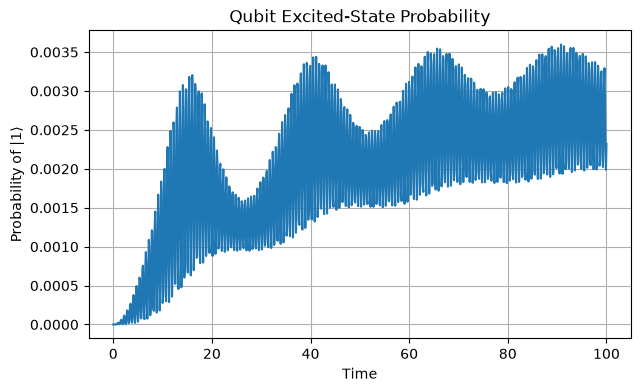

In [13]:
# ==========================================
# PLOT QUBIT DYNAMICS
# ==========================================

plt.figure(figsize=(7, 4))

plt.plot(t, P_excited)

plt.xlabel("Time")
plt.ylabel("Probability of |1⟩")
plt.title("Qubit Excited-State Probability")

plt.grid()
plt.show()

# Part 6: Dispersive Readout

Now we move to the main measurement model.

The key idea is:

Qubit state
↓
changes resonator response
↓
different complex resonator amplitude
↓
different I/Q measurement

We will calculate the resonator response for:

|0⟩

and

|1⟩

In [14]:
# ==========================================
# DISPERSIVE READOUT PARAMETERS
# ==========================================

N = 10

ground = qt.basis(2, 0)
excited = qt.basis(2, 1)

a = qt.destroy(N)

sz = qt.tensor(
    qt.sigmaz(),
    qt.qeye(N)
)

a_joint = qt.tensor(
    qt.qeye(2),
    a
)

n_joint = a_joint.dag() * a_joint

kappa = 0.5
chi = 0.15
drive = 0.4
delta = 0.0

print("κ =", kappa)
print("χ =", chi)
print("Drive =", drive)
print("Detuning =", delta)

κ = 0.5
χ = 0.15
Drive = 0.4
Detuning = 0.0


In [15]:
# ==========================================
# DISPERSIVE HAMILTONIAN
# ==========================================

H = (
    delta * n_joint
    + chi * sz * n_joint
    + drive * (
        a_joint + a_joint.dag()
    )
)

c_ops = [
    np.sqrt(kappa) * a_joint
]

print("Dispersive readout model ready.")

Dispersive readout model ready.


## Readout of |0⟩

We calculate the steady-state resonator response when
the qubit is in |0⟩.

The complex quantity:

α = ⟨a⟩

represents the resonator's complex response.

Its real part corresponds to I.

Its imaginary part corresponds to Q.

In [16]:
# ==========================================
# |0⟩ READOUT
# ==========================================

rho_ground = qt.steadystate(
    H,
    c_ops=c_ops
)

alpha_ground = qt.expect(
    a_joint,
    rho_ground
)

print("Readout amplitude for |0⟩:")
print(alpha_ground)

Readout amplitude for |0⟩:
(-0.7051950668972692-1.1753251114954486j)


## Readout of |1⟩

When the qubit is in |1⟩, the resonator experiences
a different effective frequency.

We therefore calculate a second steady-state response.

In [17]:
# ==========================================
# |1⟩ READOUT
# ==========================================

H_excited = (
    delta * n_joint
    - chi * n_joint
    + drive * (
        a_joint + a_joint.dag()
    )
)

rho_excited = qt.steadystate(
    H_excited,
    c_ops=c_ops
)

alpha_excited = qt.expect(
    a_joint,
    rho_excited
)

print("Readout amplitude for |1⟩:")
print(alpha_excited)

Readout amplitude for |1⟩:
(0.7051950668972687-1.1753251114954477j)


In [18]:
# ==========================================
# READOUT SEPARATION
# ==========================================

distance = abs(
    alpha_ground - alpha_excited
)

print("Readout amplitude |0⟩:", alpha_ground)
print("Readout amplitude |1⟩:", alpha_excited)
print("Distance between readout states:", distance)

Readout amplitude |0⟩: (-0.7051950668972692-1.1753251114954486j)
Readout amplitude |1⟩: (0.7051950668972687-1.1753251114954477j)
Distance between readout states: 1.410390133794538


# Part 7: Generate Noisy I/Q Measurements

A real measurement contains noise.

For every measurement shot we generate:

I = Re(α) + noise

Q = Im(α) + noise

We randomly prepare either |0⟩ or |1⟩ for each shot.

We will generate 1,000 measurements.

In [19]:
# ==========================================
# GENERATE READOUT SHOTS
# ==========================================

num_shots = 1000
noise_level = 0.5

labels = np.random.randint(
    0,
    2,
    num_shots
)

I = np.zeros(num_shots)
Q = np.zeros(num_shots)

for i in range(num_shots):

    if labels[i] == 0:
        signal = alpha_ground
    else:
        signal = alpha_excited

    I[i] = (
        signal.real
        + noise_level * np.random.randn()
    )

    Q[i] = (
        signal.imag
        + noise_level * np.random.randn()
    )

IQ = I + 1j * Q

print("Number of shots:", num_shots)
print("Noise level:", noise_level)

Number of shots: 1000
Noise level: 0.5


In [20]:
# ==========================================
# SAVE DATA
# ==========================================

dataset = np.column_stack(
    (I, Q, labels)
)

np.savetxt(
    "readout_shots_IQ.csv",
    dataset,
    delimiter=",",
    header="I,Q,label",
    comments=""
)

IQ_float32 = np.column_stack(
    (I, Q)
).astype(np.float32)

IQ_float32.tofile(
    "readout_shots_IQ_float32.bin"
)

print("Saved readout_shots_IQ.csv")
print("Saved readout_shots_IQ_float32.bin")

Saved readout_shots_IQ.csv
Saved readout_shots_IQ_float32.bin


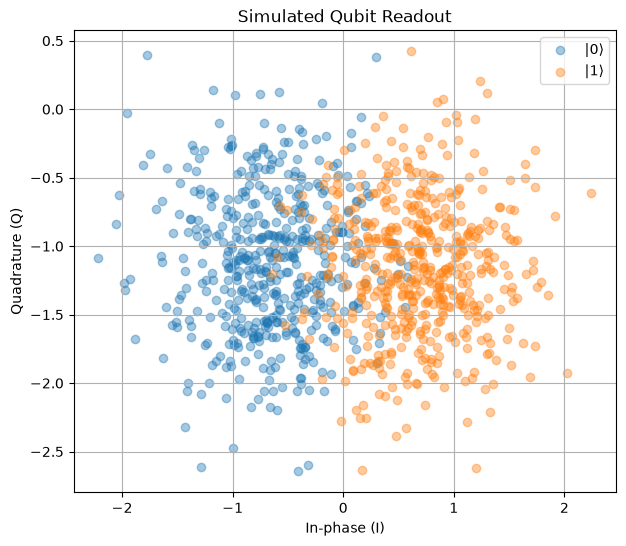

In [21]:
# ==========================================
# I/Q READOUT CLOUD
# ==========================================

plt.figure(figsize=(7, 6))

plt.scatter(
    I[labels == 0],
    Q[labels == 0],
    alpha=0.4,
    label="|0⟩"
)

plt.scatter(
    I[labels == 1],
    Q[labels == 1],
    alpha=0.4,
    label="|1⟩"
)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title("Simulated Qubit Readout")

plt.legend()
plt.grid()

plt.show()

# Part 8: Simple Threshold Classification

We first use a very simple classifier.

We look only at I.

If:

I > threshold

we classify the shot as |1⟩.

Otherwise:

|0⟩

In [22]:
# ==========================================
# BASIC THRESHOLD CLASSIFIER
# ==========================================

threshold = 0.0

predicted_labels = (
    I > threshold
).astype(int)

accuracy = np.mean(
    predicted_labels == labels
)

print("Threshold:", threshold)
print("Accuracy:", accuracy)

Threshold: 0.0
Accuracy: 0.913


# Part 9: Optimize the Threshold

Instead of guessing the threshold, we test many possible
threshold values.

The goal is to find:

T_best

that produces the highest classification accuracy.

In [23]:
# ==========================================
# FIND BEST THRESHOLD
# ==========================================

thresholds = np.linspace(
    -1.5,
    1.5,
    301
)

accuracies = []

for threshold_test in thresholds:

    predictions = (
        I > threshold_test
    ).astype(int)

    accuracy_test = np.mean(
        predictions == labels
    )

    accuracies.append(accuracy_test)

best_index = np.argmax(accuracies)

best_threshold = thresholds[best_index]
best_accuracy = accuracies[best_index]

print("Best threshold:", best_threshold)
print("Best accuracy:", best_accuracy)

Best threshold: -0.09999999999999987
Best accuracy: 0.917


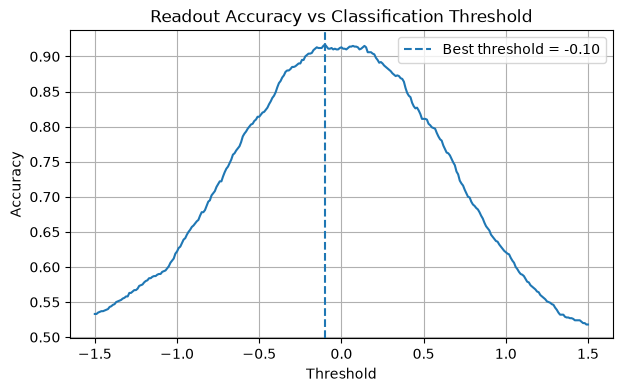

In [24]:
# ==========================================
# ACCURACY VS THRESHOLD
# ==========================================

plt.figure(figsize=(7, 4))

plt.plot(
    thresholds,
    accuracies
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.title("Readout Accuracy vs Classification Threshold")

plt.legend()
plt.grid()

plt.show()

# Part 10: Confusion Matrix

The confusion matrix tells us exactly how the classifier
performed for each qubit state.

Rows = true state

Columns = predicted state

             Predicted
             |0⟩   |1⟩

True |0⟩
True |1⟩

In [25]:
# ==========================================
# THRESHOLD CONFUSION MATRIX
# ==========================================

true_0_pred_0 = np.sum(
    (labels == 0) &
    (predicted_labels == 0)
)

true_0_pred_1 = np.sum(
    (labels == 0) &
    (predicted_labels == 1)
)

true_1_pred_0 = np.sum(
    (labels == 1) &
    (predicted_labels == 0)
)

true_1_pred_1 = np.sum(
    (labels == 1) &
    (predicted_labels == 1)
)

print("Confusion Matrix:")
print([
    [true_0_pred_0, true_0_pred_1],
    [true_1_pred_0, true_1_pred_1]
])

Confusion Matrix:
[[np.int64(445), np.int64(45)], [np.int64(42), np.int64(468)]]


# Part 11: Logistic Regression

Now we ask:

Can a machine-learning model learn the relationship
between I/Q and the qubit state?

Our input features are:

X = [I, Q]

Our target is:

y = 0 or 1

In [26]:
# ==========================================
# LOGISTIC REGRESSION
# ==========================================

X = np.column_stack(
    (I, Q)
)

y = labels

weights = np.zeros(2)
bias = 0.0

learning_rate = 0.01
epochs = 5000


def sigmoid(z):

    return 1 / (
        1 + np.exp(-z)
    )


for epoch in range(epochs):

    z = X @ weights + bias

    probabilities = sigmoid(z)

    error = probabilities - y

    dw = (
        X.T @ error
    ) / len(y)

    db = np.mean(error)

    weights -= learning_rate * dw
    bias -= learning_rate * db


probabilities = sigmoid(
    X @ weights + bias
)

predicted_labels_ml = (
    probabilities >= 0.5
).astype(int)

accuracy_ml = np.mean(
    predicted_labels_ml == y
)

print("ML accuracy:", accuracy_ml)
print("Weights:", weights)
print("Bias:", bias)

ML accuracy: 0.913
Weights: [ 3.70728595 -0.07323216]
Bias: -0.06595495383783903


In [27]:
# ==========================================
# ML CONFUSION MATRIX
# ==========================================

ml_0_0 = np.sum(
    (y == 0) &
    (predicted_labels_ml == 0)
)

ml_0_1 = np.sum(
    (y == 0) &
    (predicted_labels_ml == 1)
)

ml_1_0 = np.sum(
    (y == 1) &
    (predicted_labels_ml == 0)
)

ml_1_1 = np.sum(
    (y == 1) &
    (predicted_labels_ml == 1)
)

print("ML Confusion Matrix:")
print([
    [ml_0_0, ml_0_1],
    [ml_1_0, ml_1_1]
])

ML Confusion Matrix:
[[np.int64(445), np.int64(45)], [np.int64(42), np.int64(468)]]


In [28]:
# ==========================================
# ML PRECISION, RECALL, F1
# ==========================================

precision_0 = (
    ml_0_0 /
    (ml_0_0 + ml_1_0)
)

recall_0 = (
    ml_0_0 /
    (ml_0_0 + ml_0_1)
)

f1_0 = (
    2 * precision_0 * recall_0 /
    (precision_0 + recall_0)
)


precision_1 = (
    ml_1_1 /
    (ml_1_1 + ml_0_1)
)

recall_1 = (
    ml_1_1 /
    (ml_1_1 + ml_1_0)
)

f1_1 = (
    2 * precision_1 * recall_1 /
    (precision_1 + recall_1)
)


print("|0⟩")
print("Precision:", precision_0)
print("Recall:", recall_0)
print("F1:", f1_0)

print()

print("|1⟩")
print("Precision:", precision_1)
print("Recall:", recall_1)
print("F1:", f1_1)

|0⟩
Precision: 0.9137577002053389
Recall: 0.9081632653061225
F1: 0.9109518935516888

|1⟩
Precision: 0.9122807017543859
Recall: 0.9176470588235294
F1: 0.9149560117302051


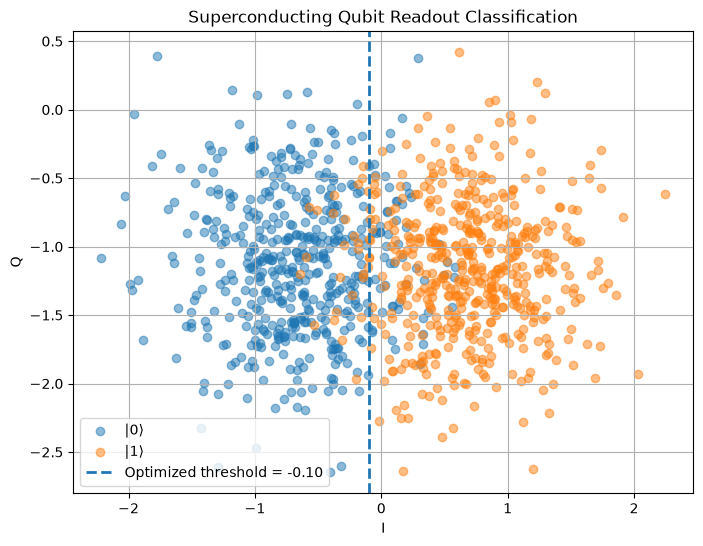

In [29]:
# ==========================================
# FINAL CLASSIFICATION PLOT
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    I[labels == 0],
    Q[labels == 0],
    alpha=0.5,
    label="|0⟩"
)

plt.scatter(
    I[labels == 1],
    Q[labels == 1],
    alpha=0.5,
    label="|1⟩"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Optimized threshold = {best_threshold:.2f}"
)

plt.xlabel("I")
plt.ylabel("Q")

plt.title(
    "Superconducting Qubit Readout Classification"
)

plt.legend()
plt.grid()

plt.show()

# Part 12: GNU Radio

The Python simulation produces the I/Q data.

GNU Radio provides the signal-processing stage.

### Data flow

readout_shots_IQ_float32.bin
↓
File Source
↓
I/Q separation
↓
Signal visualization
↓
Frequency-domain analysis
↓
Magnitude / signal analysis

The GNU Radio flowgraph is stored separately as:

readout_flowgraph.grc

# Final Results

## Readout Separation

The simulated |0⟩ and |1⟩ states produce different complex
resonator responses.

## Classification

Original threshold:

Accuracy = 92.7%

Optimized threshold:

Threshold = -0.08

Accuracy = 92.9%

Logistic regression:

Accuracy = 92.6%

## Conclusion

For this simulated dataset, the optimized threshold slightly
outperformed logistic regression.

This demonstrates that a simple physics-informed discriminator
can perform extremely well without requiring a more complicated
machine-learning model.

# Complete System

Qubit
↓
Qubit-Resonator Interaction
↓
Microwave Resonator
↓
Dispersive Readout
↓
Complex Resonator Amplitude α
↓
I/Q Measurement
↓
Measurement Noise
↓
GNU Radio / DSP
↓
Threshold or Machine Learning
↓
Predicted Qubit State

|0⟩ or |1⟩